<center><u><H1>Support Vector Machines for Classification</H1></u></center>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn import datasets
%matplotlib inline

## Preprocessing data

In [2]:
iris = datasets.load_iris()

In [3]:
X = iris.data[:,[2,3]]
Y = iris.target

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=2018)

In [5]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

## Creating a model

In [6]:
from sklearn.svm import SVC

In [7]:
svmL = SVC(kernel='linear', C=1.0)

In [8]:
svmL.fit(X_train_std, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Metrics:

In [9]:
y_pred = svmL.predict(X_test_std)

In [10]:
print(accuracy_score(Y_test,y_pred))

0.9777777777777777


In [11]:
print(confusion_matrix(Y_test, y_pred))

[[18  0  0]
 [ 0 11  0]
 [ 0  1 15]]


In [12]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.92      1.00      0.96        11
           2       1.00      0.94      0.97        16

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.97        45
weighted avg       0.98      0.98      0.98        45



## Cross Validation:

In [13]:
#  accuracy of a linear kernel support vector machine by splitting the data,
# fitting a model and computing the score 10 consecutive times (with different splits each time)
cross_val_score(svmL, X_test_std, Y_test, cv=10).mean()

np.float64(0.975)

## Plotting Decision Boundaries

In [14]:
import Plotting_Decision_Boundaries as pdb

In [15]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((Y_train, Y_test))

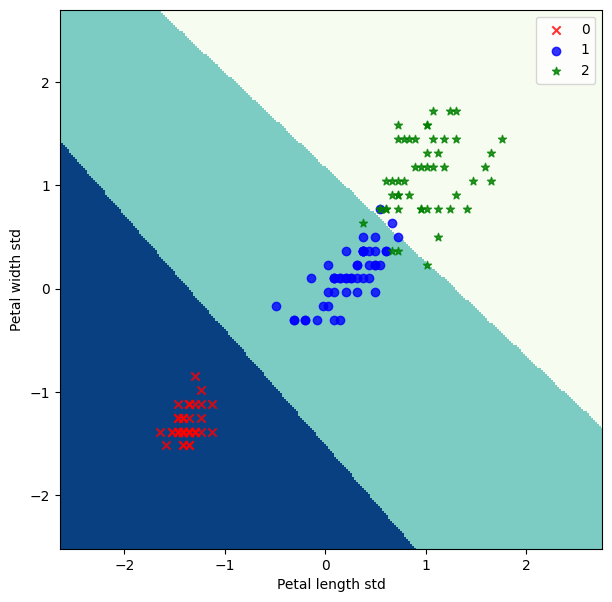

In [16]:
pdb.printing_db(X=X_combined_std,y=y_combined,model=svmL)

## Solving nonlinear models with kernel SVM:

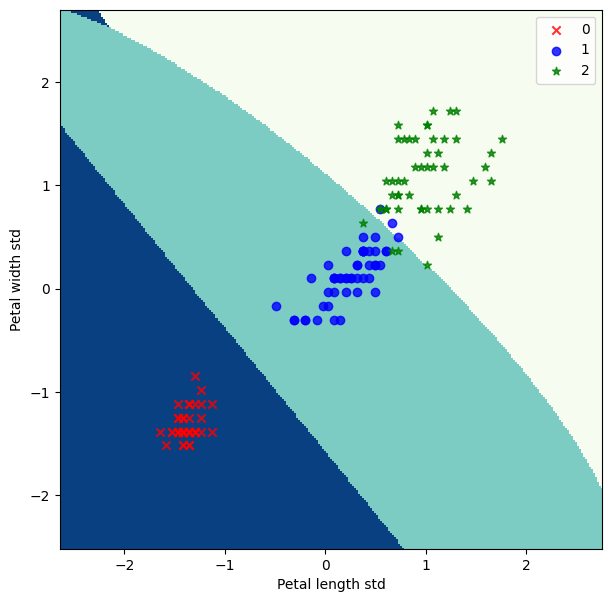

In [17]:
svm = SVC(kernel='rbf', gamma=0.1,C=10.0)
svm.fit(X_train_std, Y_train)
pdb.printing_db(X=X_combined_std,y=y_combined,model=svm)

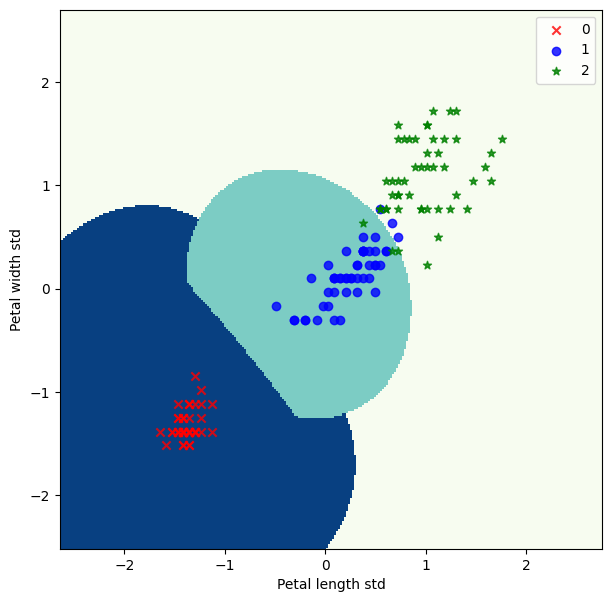

In [18]:
svm = SVC(kernel='rbf', gamma=0.5,C=10.0)
svm.fit(X_train_std, Y_train)
pdb.printing_db(X=X_combined_std,y=y_combined,model=svm)

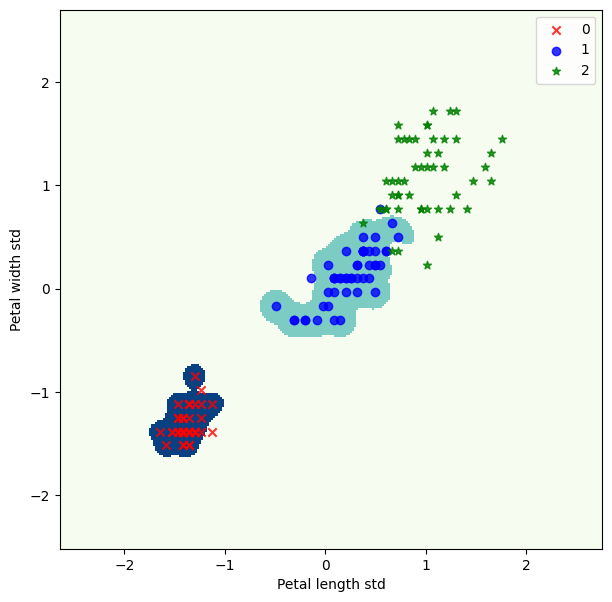

In [19]:
svm = SVC(kernel='rbf', gamma=100,C=10.0)
svm.fit(X_train_std, Y_train)
pdb.printing_db(X=X_combined_std,y=y_combined,model=svm)

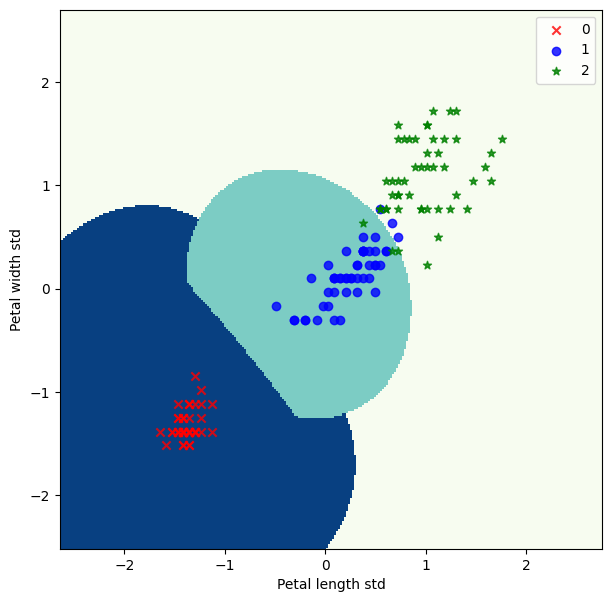

In [20]:
svm = SVC(kernel='rbf', gamma='auto',C=10.0)
svm.fit(X_train_std, Y_train)
pdb.printing_db(X=X_combined_std,y=y_combined,model=svm)

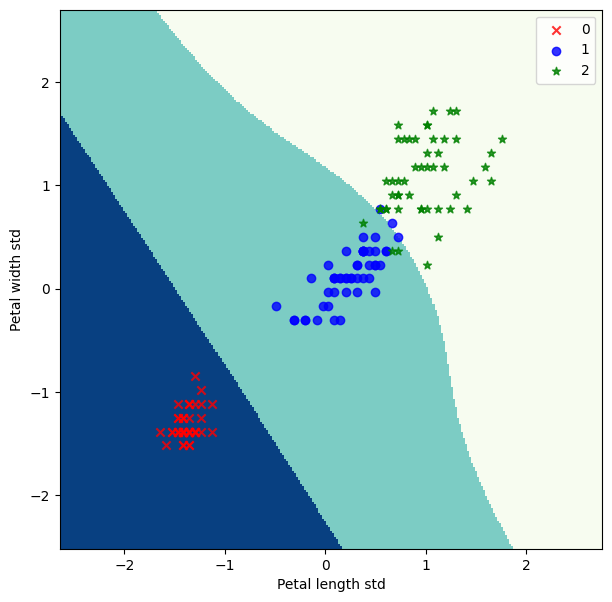

In [21]:
svm = SVC(kernel='poly', gamma='auto',C=10.0)
svm.fit(X_train_std, Y_train)
pdb.printing_db(X=X_combined_std,y=y_combined,model=svm)

## Reference: 
http://scikit-learn.org/stable/modules/svm.html